In [1]:
# Loan Default Predictor
# Importing all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Creating a realistic loan dataset
from sklearn.datasets import make_classification

# Generate synthetic loan data
X, y = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

# Convert to DataFrame with meaningful column names
df = pd.DataFrame(X, columns=[
    'income', 'age', 'loan_amount', 
    'credit_score', 'employment_years',
    'debt_ratio', 'num_credit_lines', 'payment_history'
])
df['loan_default'] = y

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1000, 9)

First 5 rows:


,income,age,loan_amount,credit_score,employment_years,debt_ratio,num_credit_lines,payment_history,loan_default
0,-1.732538,5.260112,-2.952194,-4.603768,2.235848,1.928893,-0.101845,3.193487,0
1,2.072914,2.240572,-1.385104,-2.514962,-0.984756,1.436260,-1.255271,2.089872,0
2,-0.263106,1.527781,-1.872414,-0.028009,1.612809,3.264194,-1.296421,1.537870,0
3,-0.164349,-0.550131,-0.019503,-0.765000,2.273523,2.084217,-0.321931,0.426253,0
4,-1.419423,1.015324,-0.864441,-0.009297,0.385404,0.449093,-0.029007,-1.902917,1


In [3]:
# Exploring the dataset
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   income            1000 non-null   float64
 1   age               1000 non-null   float64
 2   loan_amount       1000 non-null   float64
 3   credit_score      1000 non-null   float64
 4   employment_years  1000 non-null   float64
 5   debt_ratio        1000 non-null   float64
 6   num_credit_lines  1000 non-null   float64
 7   payment_history   1000 non-null   float64
 8   loan_default      1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB
None

Basic Statistics:


,income,age,loan_amount,credit_score,employment_years,debt_ratio,num_credit_lines,payment_history,loan_default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.005406,0.711158,-0.394057,0.532850,-0.076207,1.126541,-1.012153,0.049511,0.505000
std,1.783536,2.302393,1.825996,1.594241,1.826369,2.272793,1.240373,1.700289,0.500225
min,-5.162097,-6.054553,-7.844223,-5.446468,-5.522664,-5.495407,-5.129490,-6.274085,0.000000
25%,-1.204125,-0.863593,-1.579088,-0.534844,-1.408453,-0.401791,-1.804212,-1.080872,0.000000
50%,0.190222,0.469619,-0.452602,0.553832,-0.064367,0.874031,-1.029265,0.108569,1.000000
75%,1.262667,2.292754,0.812573,1.622359,1.200760,2.593477,-0.246030,1.240864,1.000000
max,5.379806,7.826599,5.466089,5.806373,5.526213,8.826440,3.218202,5.066045,1.000000


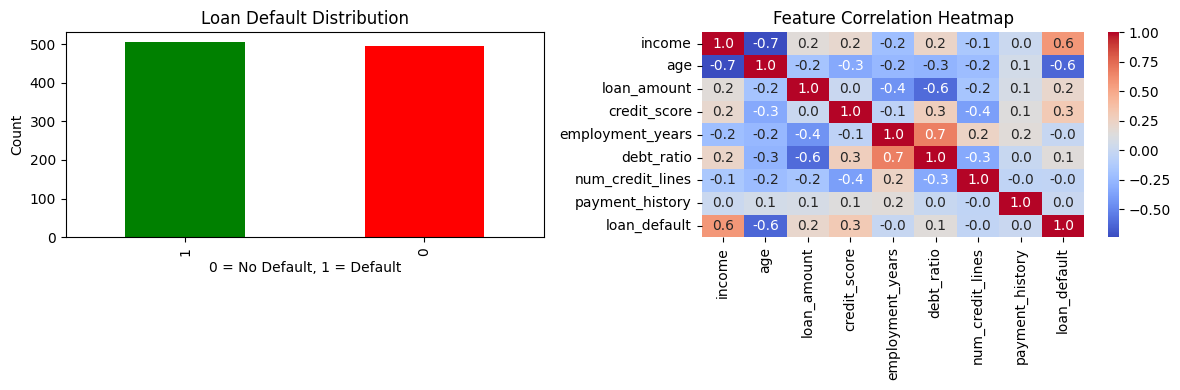

Visualizations complete!


In [4]:
# Visualizing the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - Loan Default Distribution
df['loan_default'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green', 'red']
)
axes[0].set_title('Loan Default Distribution')
axes[0].set_xlabel('0 = No Default, 1 = Default')
axes[0].set_ylabel('Count')

# Plot 2 - Correlation Heatmap
sns.heatmap(df.corr(), annot=True, fmt='.1f', 
            cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()
print("Visualizations complete!")

In [5]:
# Splitting data into training and testing sets
X = df.drop('loan_default', axis=1)
y = df['loan_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (800, 8)
Testing set size: (200, 8)


In [6]:
# Training Model 1 - Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Training Model 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Model Training Complete!")
print(f"\nLogistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"Random Forest Accuracy:       {rf_accuracy*100:.2f}%")

Model Training Complete!

Logistic Regression Accuracy: 82.00%
Random Forest Accuracy:       91.00%


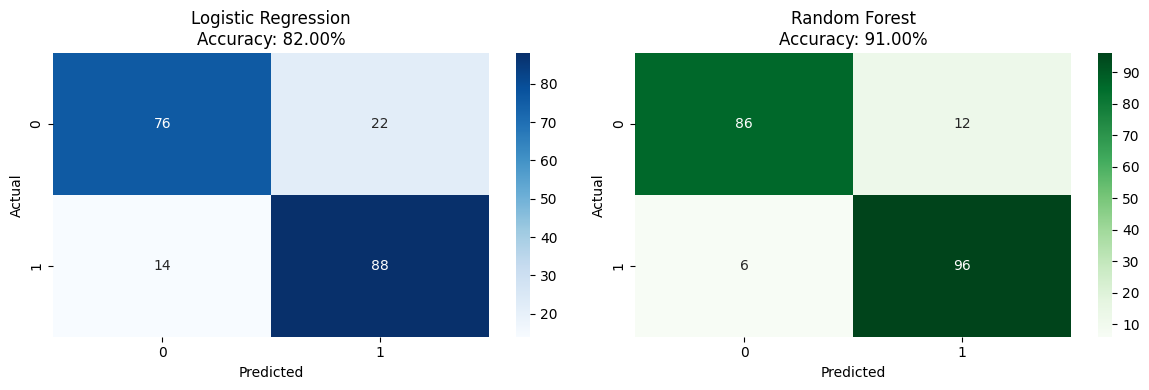


--- FINAL RESULTS ---
Logistic Regression: 82.00%
Random Forest:       91.00%

Best Model: Random Forest


In [7]:
# Detailed Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix - Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_predictions), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix - Random Forest
sns.heatmap(confusion_matrix(y_test, rf_predictions), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest\nAccuracy: {rf_accuracy*100:.2f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Final Summary
print("\n--- FINAL RESULTS ---")
print(f"Logistic Regression: {lr_accuracy*100:.2f}%")
print(f"Random Forest:       {rf_accuracy*100:.2f}%")
print(f"\nBest Model: {'Random Forest' if rf_accuracy > lr_accuracy else 'Logistic Regression'}")

C:\Windows\Temp\ipykernel_40092\1502095296.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


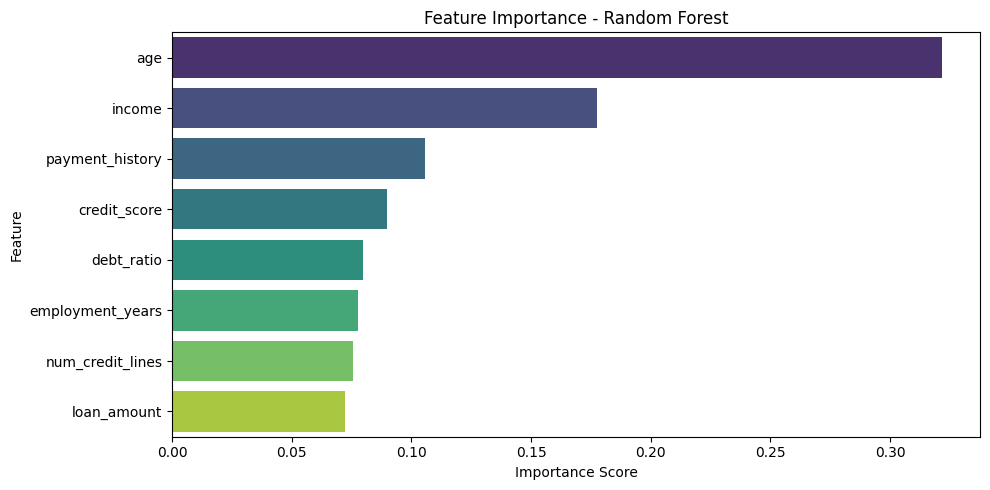


Top 3 most important features:
        feature  importance
            age    0.321570
         income    0.177744
payment_history    0.105508


In [8]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', 
            data=feature_importance, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(feature_importance.head(3).to_string(index=False))